# Applied Quantum Mechanics for Engineers

The QM that hides inside devices, done at *implementation* level — the numerical methods you'd
actually code, each checked against an analytic benchmark. Powered by the new `griffiths.quantum`
module.

| § | topic | the engineering it runs |
|---|---|---|
| 1 | finite-difference Schrödinger eigensolver | quantum-well lasers, QWIP detectors, band structure |
| 2 | tunnelling by transfer/scattering | tunnel diodes, STM, flash memory, Josephson junctions |
| 3 | harmonic-oscillator ladder | phonons, photon number states, coherent light |
| 4 | two-level Rabi dynamics | qubits, NMR, electro-optic modulators, laser gain |
| 5 | **split-operator = split-step Fourier** | **the exact propagator behind this repo's fibre work** |
| 6 | QM → ML | Hermitian operators, eigenbases, the FNO connection |

The payoff for *this* repo lands in §5: the method that evolves a wavefunction is bit-for-bit the
method that propagates an optical pulse down a dispersive fibre.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from griffiths import quantum as q

print("griffiths.quantum loaded; natural units hbar = m = 1")

griffiths.quantum loaded; natural units hbar = m = 1


## §1 The workhorse: a finite-difference Schrödinger eigensolver

Discretise $-\tfrac{\hbar^2}{2m}\psi'' + V\psi = E\psi$ on a grid: the second derivative becomes a
tridiagonal matrix, and the bound states are its eigenvectors. This one routine handles *any*
$V(x)$ — the analytic infinite well and harmonic oscillator below are just free verification.
A real quantum-well laser's conduction-band profile goes in the same slot.

infinite well, E_n:
  n=1: numeric    4.925   analytic    4.935   (FD error -0.20%)
  n=2: numeric   19.700   analytic   19.739   (FD error -0.20%)
  n=3: numeric   44.324   analytic   44.413   (FD error -0.20%)
  n=4: numeric   78.799   analytic   78.957   (FD error -0.20%)
  n=5: numeric  123.123   analytic  123.370   (FD error -0.20%)


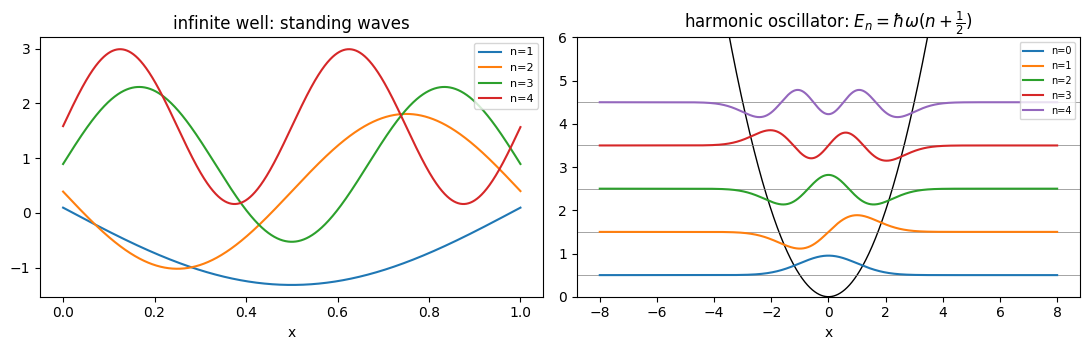

HO spacing (numeric): [1. 1. 1. 1. 1.]  -> uniform hbar*omega = 1


In [2]:
# infinite square well: numeric eigenvalues vs n^2 pi^2 / (2 L^2)
L = 1.0
x = np.linspace(0, L, 2000)
E_num, psi = q.solve_tise(x, np.zeros_like(x), n_states=5)
E_ana = q.infinite_well_energies(np.arange(1, 6), L)
print("infinite well, E_n:")
for n, (en, ea) in enumerate(zip(E_num, E_ana), 1):
    print(f"  n={n}: numeric {en:8.3f}   analytic {ea:8.3f}   "
          f"(FD error {(en-ea)/ea:+.2%})")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for n in range(4):
    axes[0].plot(x, psi[:, n] + E_num[n]*0.02, label=f"n={n+1}")
axes[0].set_title("infinite well: standing waves"); axes[0].legend(fontsize=8)
axes[0].set_xlabel("x")

# harmonic oscillator: levels and the equal hbar*omega spacing
xh = np.linspace(-8, 8, 3000)
Vh = 0.5 * xh**2
Eh, psih = q.solve_tise(xh, Vh, n_states=6)
axes[1].plot(xh, Vh, "k", lw=1)
for n in range(5):
    axes[1].axhline(Eh[n], color="gray", lw=0.5)
    axes[1].plot(xh, 0.6*psih[:, n] + Eh[n], label=f"n={n}")
axes[1].set_ylim(0, 6)
axes[1].set_title(r"harmonic oscillator: $E_n=\hbar\omega(n+\frac{1}{2})$")
axes[1].set_xlabel("x"); axes[1].legend(fontsize=7, loc="upper right")
plt.tight_layout(); plt.show()
print("HO spacing (numeric):", np.round(np.diff(Eh), 4), " -> uniform hbar*omega = 1")

## §2 Tunnelling: the effect that runs the device shelf

A particle with $E < V_0$ still leaks through a barrier with probability $T(E)$. That leak *is* the
tunnel diode, the scanning tunnelling microscope (current $\propto e^{-2\kappa d}$ — the exponential
sensitivity that resolves single atoms), Fowler–Nordheim injection in flash memory, and the
Josephson junction. The module integrates the scattering state numerically; the rectangular barrier
has a closed form for checking.

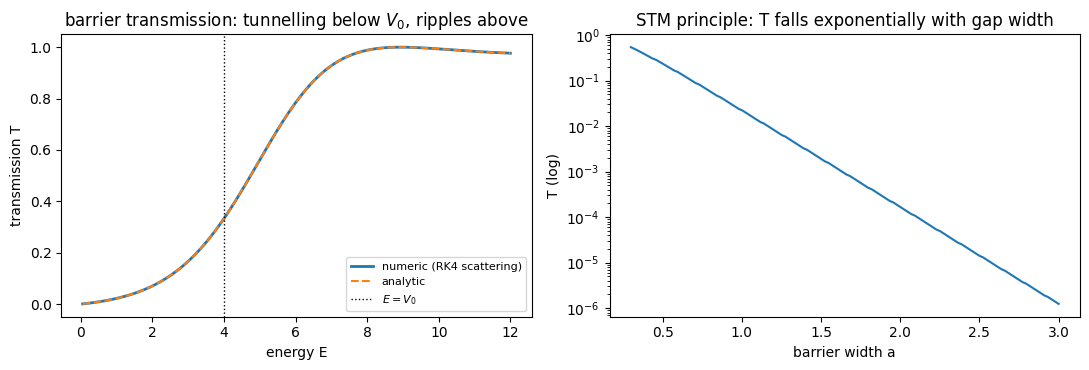

max |T_num - T_ana| over the sweep: 1.17e-04


In [3]:
xb = np.linspace(-8, 8, 4000)
V0, a = 4.0, 1.0
Vb = np.where(np.abs(xb) < a/2, V0, 0.0)

E_grid = np.linspace(0.05, 12, 250)
T_num = np.array([q.transmission(xb, Vb, E) for E in E_grid])
T_ana = np.array([q.rectangular_barrier_T(E, V0, a) for E in E_grid])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(E_grid, T_num, lw=2, label="numeric (RK4 scattering)")
axes[0].plot(E_grid, T_ana, "--", lw=1.5, label="analytic")
axes[0].axvline(V0, color="k", ls=":", lw=1, label=r"$E=V_0$")
axes[0].set_xlabel("energy E"); axes[0].set_ylabel("transmission T")
axes[0].set_title("barrier transmission: tunnelling below $V_0$, ripples above")
axes[0].legend(fontsize=8)

# STM payoff: exponential dependence on barrier width = atomic-scale sensitivity
widths = np.linspace(0.3, 3.0, 120)
T_w = [q.transmission(np.linspace(-8, 8, 4000),
        np.where(np.abs(np.linspace(-8, 8, 4000)) < w/2, V0, 0.0), 1.0) for w in widths]
axes[1].semilogy(widths, T_w)
axes[1].set_xlabel("barrier width a"); axes[1].set_ylabel("T (log)")
axes[1].set_title("STM principle: T falls exponentially with gap width")
plt.tight_layout(); plt.show()
print(f"max |T_num - T_ana| over the sweep: {np.max(np.abs(T_num-T_ana)):.2e}")

## §3 The ladder: one operator algebra for phonons, photons, and light

The harmonic oscillator's raising/lowering operators $a^\dagger, a$ are the universal currency of
*quantised anything*: lattice vibrations (phonons), the EM field (photons), vibrational modes.
$a^\dagger a = \hat N$ counts quanta; a **coherent state** $|\alpha\rangle$ — the eigenstate of $a$
— is the quantum description of laser light, with a Poisson photon-number distribution of mean
$|\alpha|^2$.

number operator a_dag a is diagonal with eigenvalues 0,1,2,...: True
  |alpha=1.0>:  <n>=1.000  Var(n)=1.000  (Poisson => equal, |alpha|^2=1.0)
  |alpha=2.0>:  <n>=4.000  Var(n)=4.000  (Poisson => equal, |alpha|^2=4.0)
  |alpha=3.0>:  <n>=9.000  Var(n)=9.000  (Poisson => equal, |alpha|^2=9.0)


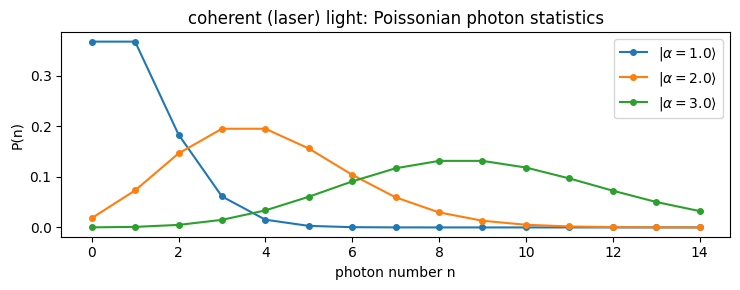

In [4]:
a, ad = q.ladder_operators(60)
N = ad @ a
print("number operator a_dag a is diagonal with eigenvalues 0,1,2,...:",
      np.allclose(N, np.diag(np.arange(61))))

# coherent state photon statistics: Poisson with mean |alpha|^2
for alpha in (1.0, 2.0, 3.0):
    psi = q.coherent_state(alpha, 60)
    p_n = np.abs(psi)**2
    mean_n = np.sum(np.arange(61) * p_n)
    var_n = np.sum((np.arange(61) - mean_n)**2 * p_n)
    print(f"  |alpha={alpha}>:  <n>={mean_n:.3f}  Var(n)={var_n:.3f}  "
          f"(Poisson => equal, |alpha|^2={alpha**2:.1f})")

plt.figure(figsize=(7.5, 3))
for alpha in (1.0, 2.0, 3.0):
    p_n = np.abs(q.coherent_state(alpha, 60))**2
    plt.plot(np.arange(15), p_n[:15], "o-", ms=4, label=fr"$|\alpha={alpha}\rangle$")
plt.xlabel("photon number n"); plt.ylabel("P(n)")
plt.title("coherent (laser) light: Poissonian photon statistics")
plt.legend(); plt.tight_layout(); plt.show()

## §4 Two-level dynamics: the qubit, the modulator, the spin

Drive a two-level system and the population sloshes between levels at the Rabi frequency $\Omega$.
A **$\pi$-pulse** (area $\Omega t = \pi$) fully inverts it — that is an X-gate on a qubit, a spin
flip in NMR/MRI, and the population-inversion engine of a laser. Detuning $\delta$ both speeds the
oscillation ($\sqrt{\Omega^2+\delta^2}$) and caps its amplitude — the resonance lineshape every RF
and electro-optic engineer fights.

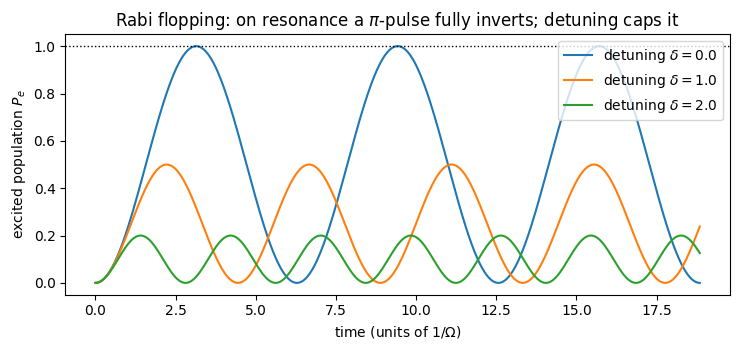

on-resonance pi-pulse inversion: 1.0


In [5]:
t = np.linspace(0, 6*np.pi, 600)
plt.figure(figsize=(7.5, 3.6))
for delta in (0.0, 1.0, 2.0):
    plt.plot(t, q.rabi_evolution(t, Omega=1.0, delta=delta),
             label=fr"detuning $\delta={delta}$")
plt.axhline(1, color="k", ls=":", lw=1)
plt.xlabel(r"time (units of $1/\Omega$)"); plt.ylabel(r"excited population $P_e$")
plt.title("Rabi flopping: on resonance a $\\pi$-pulse fully inverts; detuning caps it")
plt.legend(); plt.tight_layout(); plt.show()

print("on-resonance pi-pulse inversion:", round(float(q.rabi_evolution(np.pi, 1.0, 0.0)), 4))

## §5 The bridge: split-operator evolution **is** the split-step Fourier method

The time-dependent Schrödinger equation and the optical-pulse equation are the *same equation*:

$$i\frac{\partial\psi}{\partial t} = -\frac{\hbar}{2m}\frac{\partial^2\psi}{\partial x^2} + \frac{V}{\hbar}\psi
\qquad\longleftrightarrow\qquad
i\frac{\partial A}{\partial z} = \frac{\beta_2}{2}\frac{\partial^2 A}{\partial T^2} - \gamma|A|^2 A$$

with the dictionary **time $t\leftrightarrow$ distance $z$**, **kinetic term $\leftrightarrow$
group-velocity dispersion $\beta_2$**, **potential $\leftrightarrow$ nonlinearity $\gamma|A|^2$**.
So the split-operator integrator — apply the potential in real space, the kinetic term in Fourier
space, Strang-split — *is* the split-step Fourier method that this repo uses to propagate pulses.
Learn one, you have implemented the other.

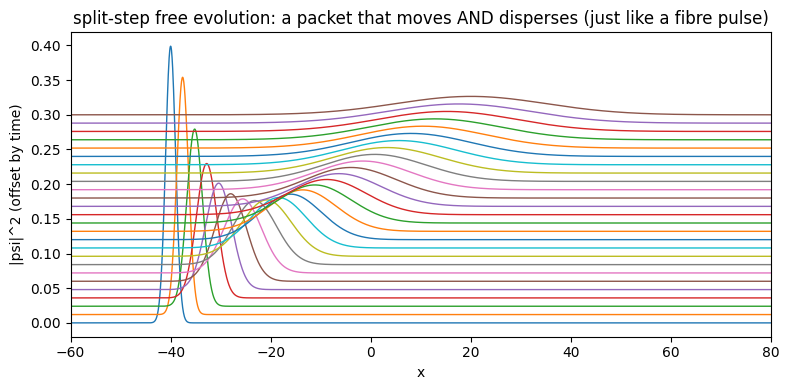

after t=30: width numeric 15.033 vs analytic 15.033 (rel err +0.00%); norm 1.000000 (unitary)


: 

In [ ]:
# free-particle spreading: the split-step propagator vs the analytic Gaussian width.
# Big box keeps the moving packet interior so the periodic FFT edges never wrap it.
xg = np.linspace(-120, 120, 4096)
sigma0 = 1.0
psi0 = q.gaussian_packet(xg, x0=-40.0, k0=2.0, sigma=sigma0)   # moving packet
dt, steps, every = 0.02, 1500, 60
frames = q.split_step(psi0, xg, np.zeros_like(xg), dt, steps, store_every=every)

plt.figure(figsize=(8, 4))
for i in range(frames.shape[0]):
    plt.plot(xg, np.abs(frames[i])**2 + 0.012*i, lw=1)
plt.xlim(-60, 80)
plt.xlabel("x"); plt.ylabel("|psi|^2 (offset by time)")
plt.title("split-step free evolution: a packet that moves AND disperses (just like a fibre pulse)")
plt.tight_layout(); plt.show()

# quantitative check: numeric width vs sigma(t) = sigma0 sqrt(1 + (t/2 sigma0^2)^2)
dx = xg[1]-xg[0]
dens = np.abs(frames[-1])**2
mean = np.sum(xg*dens)*dx
sig_num = np.sqrt(np.sum((xg-mean)**2*dens)*dx)
t_end = dt*steps
sig_ana = sigma0*np.sqrt(1 + (t_end/(2*sigma0**2))**2)
print(f"after t={t_end:.0f}: width numeric {sig_num:.3f} vs analytic {sig_ana:.3f} "
      f"(rel err {(sig_num-sig_ana)/sig_ana:+.2%}); norm {np.sum(dens)*dx:.6f} (unitary)")

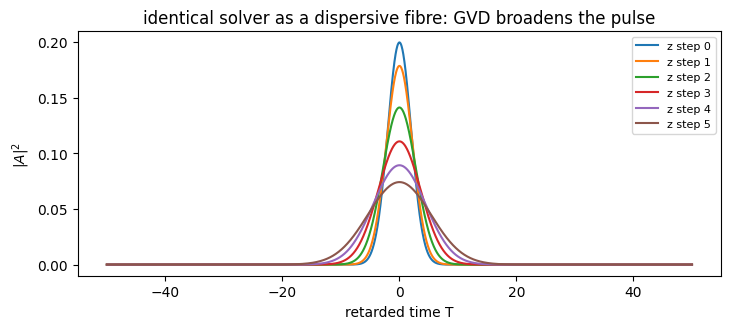

dispersion provides the diversity TD-GS needs -- this is the repo's physics, in one solver.


In [7]:
# the SAME code, reinterpreted as a fibre: a chirp-free pulse broadening under GVD.
# beta2 plays the role of hbar/m; T (retarded time) plays the role of x.
T = np.linspace(-50, 50, 2048)
A0 = q.gaussian_packet(T, x0=0.0, k0=0.0, sigma=2.0)      # transform-limited pulse
beta2 = 1.0                                               # anomalous-like, |D| set by this
# dispersion-only propagation == free-particle Schrodinger with hbar/m = beta2
frames_fib = q.split_step(A0, T, np.zeros_like(T), dt=0.05, steps=400,
                          hbar=beta2, m=1.0, store_every=80)
plt.figure(figsize=(7.5, 3.4))
for i, fr in enumerate(frames_fib):
    plt.plot(T, np.abs(fr)**2, label=f"z step {i}")
plt.xlabel("retarded time T"); plt.ylabel(r"$|A|^2$")
plt.title("identical solver as a dispersive fibre: GVD broadens the pulse")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()
print("dispersion provides the diversity TD-GS needs -- this is the repo's physics, in one solver.")

## §6 The Griffiths → ML axis, quantum edition

- **Hermitian operators → real spectra → stable computation.** $H = H^\dagger$ guarantees real
  eigenvalues and orthogonal eigenvectors — the same property that makes a symmetric attention/
  covariance matrix diagonalisable and PCA well-posed. The eigensolver in §1 is `np.linalg.eigh`,
  the exact call behind PCA.
- **Eigenstates are an optimal basis.** Expanding a state in energy eigenstates is the physics name
  for projecting data onto principal components; truncating high modes is model compression.
- **The split-step/Fourier view → neural operators.** §5 propagates by multiplying in the Fourier
  domain — precisely the spectral-convolution layer of the FNO in `gs_fno.py`. A learned FNO is
  this physics with the kinetic/dispersion kernel replaced by trained spectral weights.
- **Unitarity → norm-preserving nets.** Split-step evolution conserves $\|\psi\|$ exactly; the same
  idea underlies unitary/orthogonal RNNs that dodge exploding gradients.

*Module added this session:* `griffiths/quantum.py` (FD eigensolver, scattering transmission,
ladder operators, Rabi, split-operator propagator), all benchmarked in `scripts/smoke_quantum.py`.